<a href="https://colab.research.google.com/github/fidiadwi/ProjectComvisKelompok3/blob/main/COMVISYOLO8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Deteksi Huruf Kaganga Aksara Ulu Rejang menggunakan YOLOv8**

In [ ]:
## CELL 1 - INSTALL LIBRARY

!pip install ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 140.9 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.13
    Uninstalling idna-3.13:
      Successfully uninstalled idna-3.13


In [ ]:
## CELL 2 - IMPORT LIBRARY

from roboflow import Roboflow
from ultralytics import YOLO

import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [ ]:
## CELL 3 - DATASET

rf = Roboflow(api_key="nzMeEHfWoQkXcBy5K6KS")

project = rf.workspace(
    "novalrizkiansyah-ymail-com"
).project(
    "aksara-ulu-rejang"
)

version = project.version(4)

dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Aksara-Ulu-Rejang-4 in yolov8:: 100%|██████████| 3271/3271 [00:01<00:00, 2572.14it/s]


In [ ]:
## CELL 4 - HAPUS HASIL TRAINING LAMA

!rm -rf /content/runs/detect/train
!rm -rf /content/runs/detect/predict

In [ ]:
## CELL 5 - CEK STRUKTUR DATASET

print(os.listdir("/content/Aksara-Ulu-Rejang-4"))

['train', 'data.yaml', 'valid', 'test', 'README.roboflow.txt', 'README.dataset.txt']


In [ ]:
## CELL 6 - CEK DATA.YAML

yaml_path = "/content/Aksara-Ulu-Rejang-4/data.yaml"

with open(yaml_path, "r") as f:
    print(f.read())

names:
- a
- ah
- an
- ang
- ar
- aw
- ay
- ba
- bah
- ban
- bang
- bar
- baw
- bay
- be
- bi
- bo
- bu
- ca
- cah
- can
- cang
- car
- caw
- cay
- ce
- ci
- co
- cu
- da
- dah
- dan
- dang
- dar
- daw
- day
- de
- di
- do
- du
- e
- ga
- gah
- gan
- gang
- gar
- gaw
- gay
- ge
- gi
- go
- gu
- ha
- hah
- han
- hang
- har
- haw
- hay
- he
- hi
- ho
- hu
- i
- ja
- jah
- jan
- jang
- jar
- jaw
- jay
- je
- ji
- jo
- ju
- ka
- kah
- kan
- kang
- kar
- kaw
- kay
- ke
- ki
- ko
- ku
- la
- lah
- lan
- lang
- lar
- law
- lay
- le
- li
- lo
- lu
- ma
- mah
- man
- mang
- mar
- maw
- may
- mba
- mbah
- mban
- mbang
- mbar
- mbaw
- mbay
- mbe
- mbi
- mbo
- mbu
- me
- mi
- mo
- mu
- na
- nah
- nan
- nang
- nar
- naw
- nay
- nda
- ndah
- ndan
- ndang
- ndar
- ndaw
- nday
- nde
- ndi
- ndo
- ndu
- ne
- nga
- ngah
- ngan
- ngang
- ngar
- ngaw
- ngay
- nge
- ngga
- nggah
- nggan
- nggang
- nggar
- nggaw
- nggay
- ngge
- nggi
- nggo
- nggu
- ngi
- ngo
- ngu
- ni
- nja
- njah
- njan
- njang
- njar
- 

In [ ]:
## CELL 7 - TRAINING YOLOV8

model = YOLO("yolov8m.pt")

results = model.train(
    data="/content/Aksara-Ulu-Rejang-4/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    plots=True,
    save=True
)

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Aksara-Ulu-Rejang-4/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pati

In [ ]:
## CELL 8 - CEK HASIL TRAINING

train_path = "/content/runs/detect/train"

print(os.listdir(train_path))

['args.yaml', 'val_batch0_labels.jpg', 'train_batch3520.jpg', 'results.png', 'weights', 'BoxP_curve.png', 'BoxR_curve.png', 'val_batch2_pred.jpg', 'BoxPR_curve.png', 'confusion_matrix.png', 'results.csv', 'val_batch2_labels.jpg', 'labels.jpg', 'val_batch1_labels.jpg', 'train_batch1.jpg', 'confusion_matrix_normalized.png', 'train_batch3522.jpg', 'train_batch0.jpg', 'BoxF1_curve.png', 'val_batch1_pred.jpg', 'train_batch2.jpg', 'train_batch3521.jpg', 'val_batch0_pred.jpg']


File grafik:
['results.png', 'BoxP_curve.png', 'BoxR_curve.png', 'BoxPR_curve.png', 'confusion_matrix.png', 'confusion_matrix_normalized.png', 'BoxF1_curve.png']


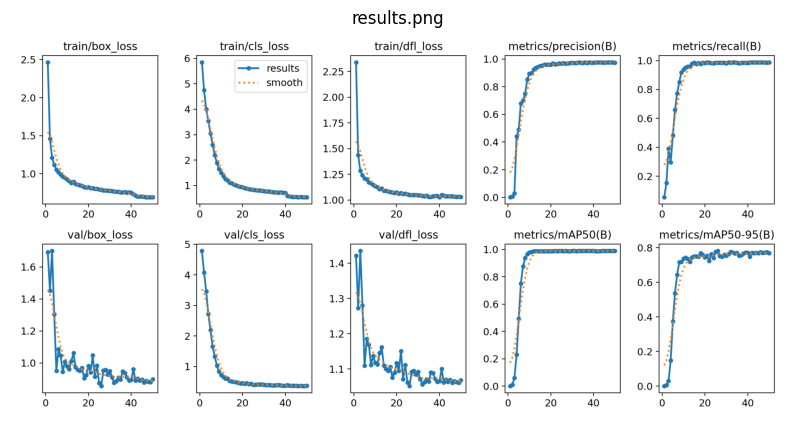

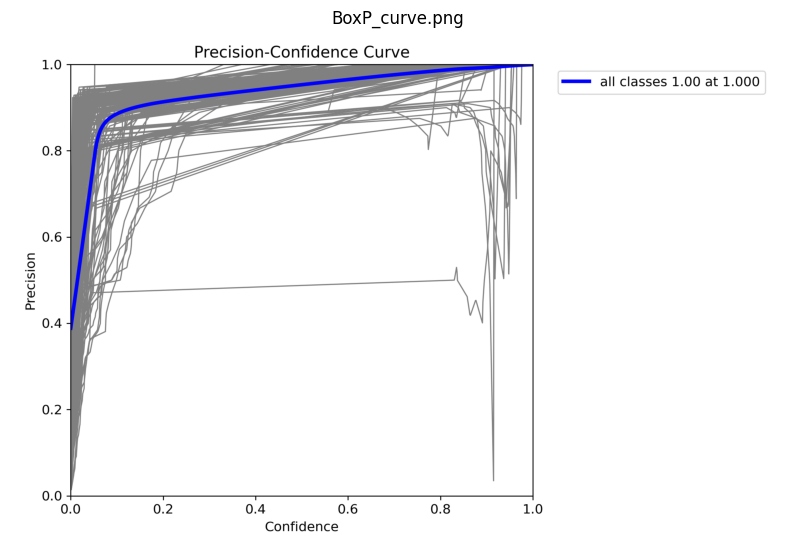

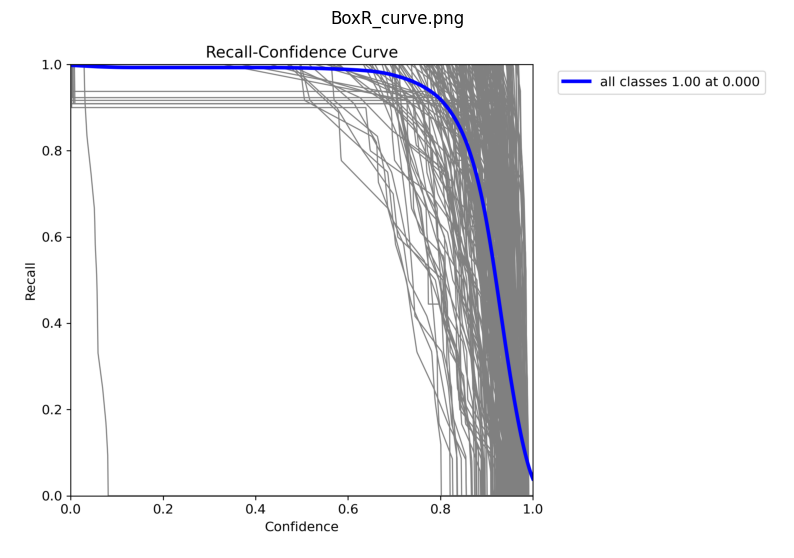

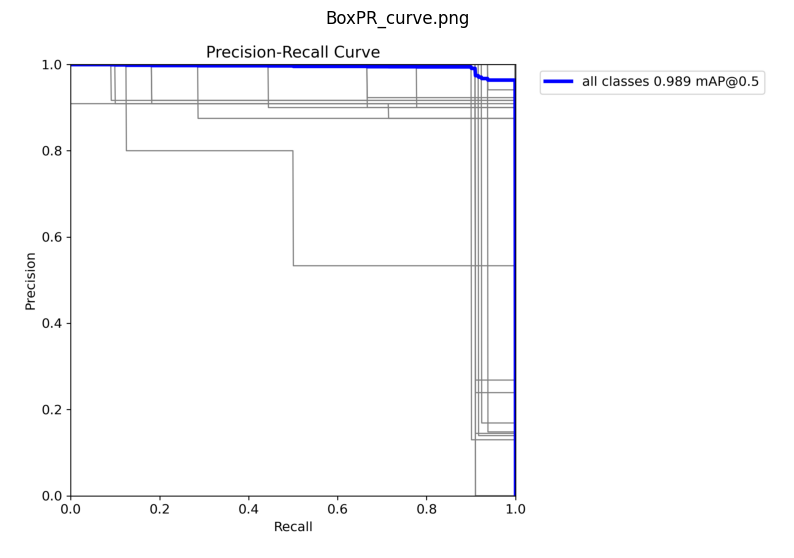

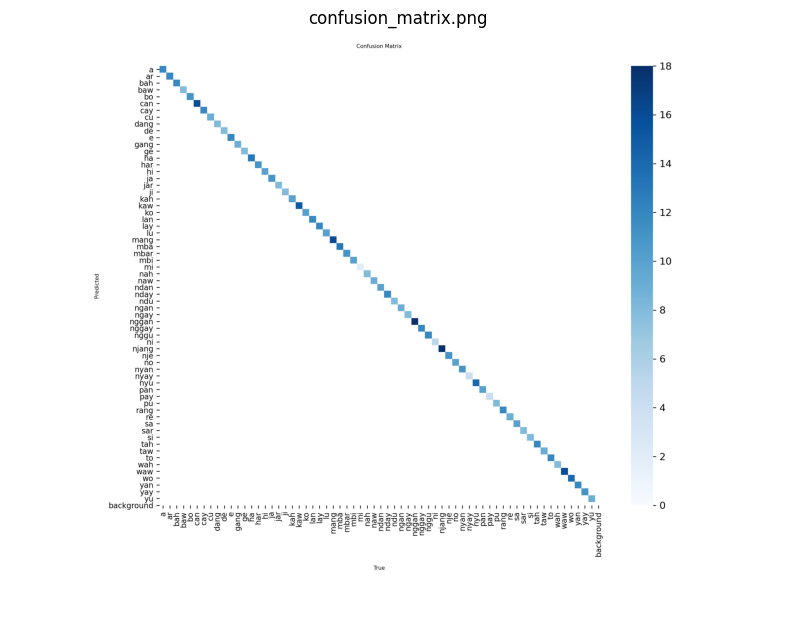

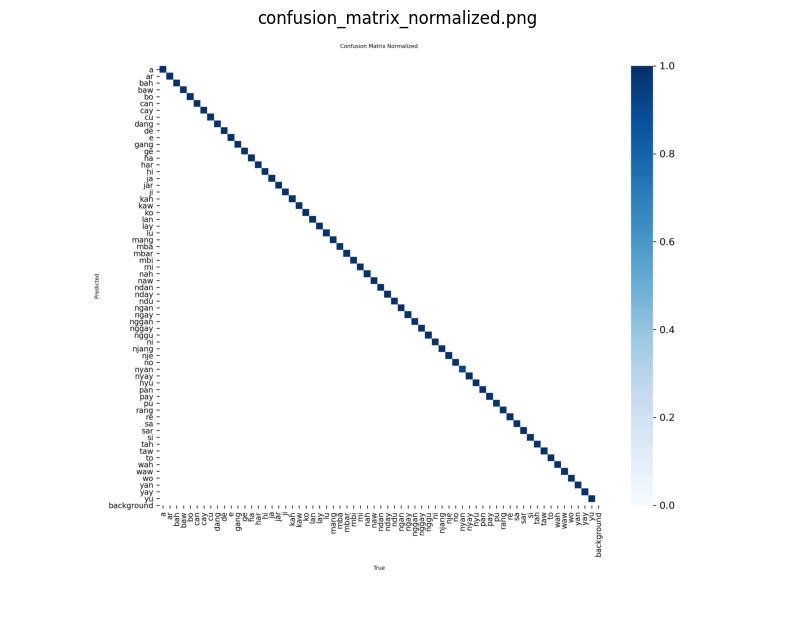

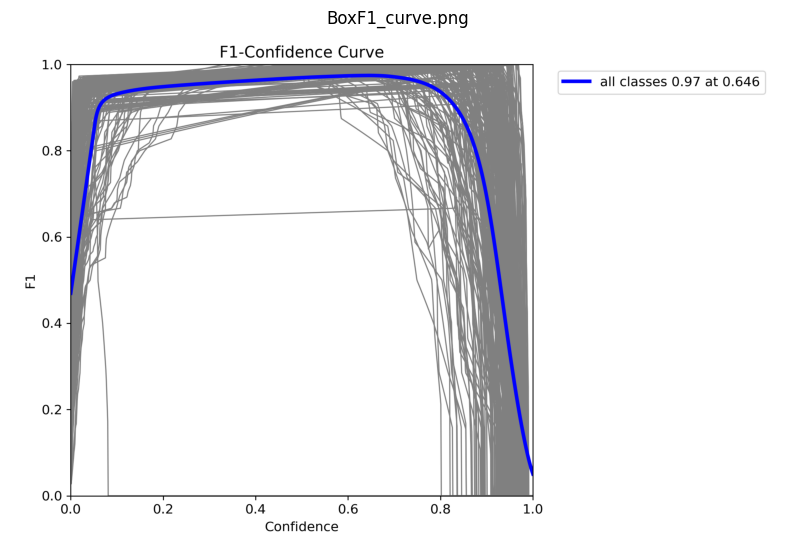

In [ ]:
## CELL 9 - TAMPILKAN GRAFIK TRAINING

png_files = [
    f for f in os.listdir(train_path)
    if f.endswith(".png")
]

print("File grafik:")
print(png_files)

for file in png_files:

    img_path = os.path.join(train_path, file)

    img = mpimg.imread(img_path)

    plt.figure(figsize=(10,8))
    plt.imshow(img)

    plt.title(file)

    plt.axis("off")

    plt.show()

In [ ]:
## CELL 10 - LOAD MODEL TERBAIK

best_model = YOLO(
    "/content/runs/detect/train/weights/best.pt"
)

In [ ]:
## CELL 11 - PREDIKSI GAMBAR

from ultralytics import YOLO

best_model = YOLO("/content/runs/detect/train/weights/best.pt")

results = best_model.predict(
    source="/content/dataset/train/images",
    save=True,
    conf=0.01,
    line_width=2,
    show_labels=True,
    show_conf=True
)


image 1/479 /content/dataset/train/images/100_jpg.rf.cb5f610f415e10ca77530a26f9d5c12e.jpg: 640x640 2 dars, 2 daws, 2 mbars, 2 nars, 2 naws, 1 ni, 1 nyaw, 2 pars, 2 paws, 1 sar, 37.4ms
image 2/479 /content/dataset/train/images/101_jpg.rf.4d6f6d4fe24851116c4d8c71700a93fb.jpg: 640x640 2 days, 2 nays, 2 pays, 37.4ms
image 3/479 /content/dataset/train/images/102_jpg.rf.b24dd082e2dac190fb29072cbee115fa.jpg: 640x640 5 days, 4 nays, 4 pays, 26.5ms
image 4/479 /content/dataset/train/images/107_jpg.rf.43d2c19f28ad79f1f5d95ff3d29935c7.jpg: 640x640 1 bay, 2 days, 1 gay, 2 nays, 2 pays, 26.6ms
image 5/479 /content/dataset/train/images/108_jpg.rf.dde179b8870bedb2f15a4b5bba87124e.jpg: 640x640 8 bas, 2 bes, 2 bis, 2 bus, 6 cas, 2 cis, 1 ki, 6 mas, 2 mes, 2 mis, 26.7ms
image 6/479 /content/dataset/train/images/109_jpg.rf.bbcebefcc04c567ae012525743295564.jpg: 640x640 4 bas, 4 bes, 6 bis, 1 bu, 4 cas, 11 cis, 2 kis, 4 mas, 4 mes, 6 mis, 26.8ms
image 7/479 /content/dataset/train/images/10_jpg.rf.5be0c71c

In [ ]:
## CELL 12 CEK POLDER PREDICT
predict_folder = "/content/runs/detect/predict"
print(os.listdir(predict_folder))

['635_jpg.rf.86431792f72b0e3da95e6172fe40f8f2.jpg', '480_jpg.rf.ff3d3b89c18389f0a3557cb7b7755724.jpg', '89_jpg.rf.3638e8d9f1bdba4f5593ff0c0b4a0d54.jpg', '491_jpg.rf.eec36c835752047c71187180d916b0ef.jpg', '675_jpg.rf.f77c8a82dd96d9e8a16c38d72806a16b.jpg', '547_jpg.rf.0517e4b8453327236d2954fb14dcc755.jpg', '420_jpg.rf.750591bb0229d9f80f378341e81a98e7.jpg', '232_jpg.rf.15474eea671ae9c781f739dfd17fd49d.jpg', '467_jpg.rf.61bfc7dad79b0724711383c595cd459f.jpg', '297_jpg.rf.2cf6f6f84d76edd97dec97de3b63e693.jpg', '601_jpg.rf.ecd2c8d6f0f11a9361d187e88274c574.jpg', '383_jpg.rf.8dab2c45e7498daabe35cc5e18317847.jpg', '282_jpg.rf.d34a68b1cb4ba09a517e967566586b67.jpg', '597_jpg.rf.c4430e5c146efe146bfd0c93fb5c20aa.jpg', '564_jpg.rf.fac0f8cdc16de7c437cab3454fed43a6.jpg', '489_jpg.rf.eeba2682e9621806b0d7d71d0edd6646.jpg', '130_jpg.rf.abad26f41d85ff7238cf08b24ff20ed3.jpg', '355_jpg.rf.e582adb89a88e62a81a27b5155bf1c89.jpg', '270_jpg.rf.e15d37e6112d6215ab69e9270a83ef0e.jpg', '104_jpg.rf.81823e61e224273562e

['635_jpg.rf.86431792f72b0e3da95e6172fe40f8f2.jpg', '480_jpg.rf.ff3d3b89c18389f0a3557cb7b7755724.jpg', '89_jpg.rf.3638e8d9f1bdba4f5593ff0c0b4a0d54.jpg', '491_jpg.rf.eec36c835752047c71187180d916b0ef.jpg', '675_jpg.rf.f77c8a82dd96d9e8a16c38d72806a16b.jpg', '547_jpg.rf.0517e4b8453327236d2954fb14dcc755.jpg', '420_jpg.rf.750591bb0229d9f80f378341e81a98e7.jpg', '232_jpg.rf.15474eea671ae9c781f739dfd17fd49d.jpg', '467_jpg.rf.61bfc7dad79b0724711383c595cd459f.jpg', '297_jpg.rf.2cf6f6f84d76edd97dec97de3b63e693.jpg', '601_jpg.rf.ecd2c8d6f0f11a9361d187e88274c574.jpg', '383_jpg.rf.8dab2c45e7498daabe35cc5e18317847.jpg', '282_jpg.rf.d34a68b1cb4ba09a517e967566586b67.jpg', '597_jpg.rf.c4430e5c146efe146bfd0c93fb5c20aa.jpg', '564_jpg.rf.fac0f8cdc16de7c437cab3454fed43a6.jpg', '489_jpg.rf.eeba2682e9621806b0d7d71d0edd6646.jpg', '130_jpg.rf.abad26f41d85ff7238cf08b24ff20ed3.jpg', '355_jpg.rf.e582adb89a88e62a81a27b5155bf1c89.jpg', '270_jpg.rf.e15d37e6112d6215ab69e9270a83ef0e.jpg', '104_jpg.rf.81823e61e224273562e

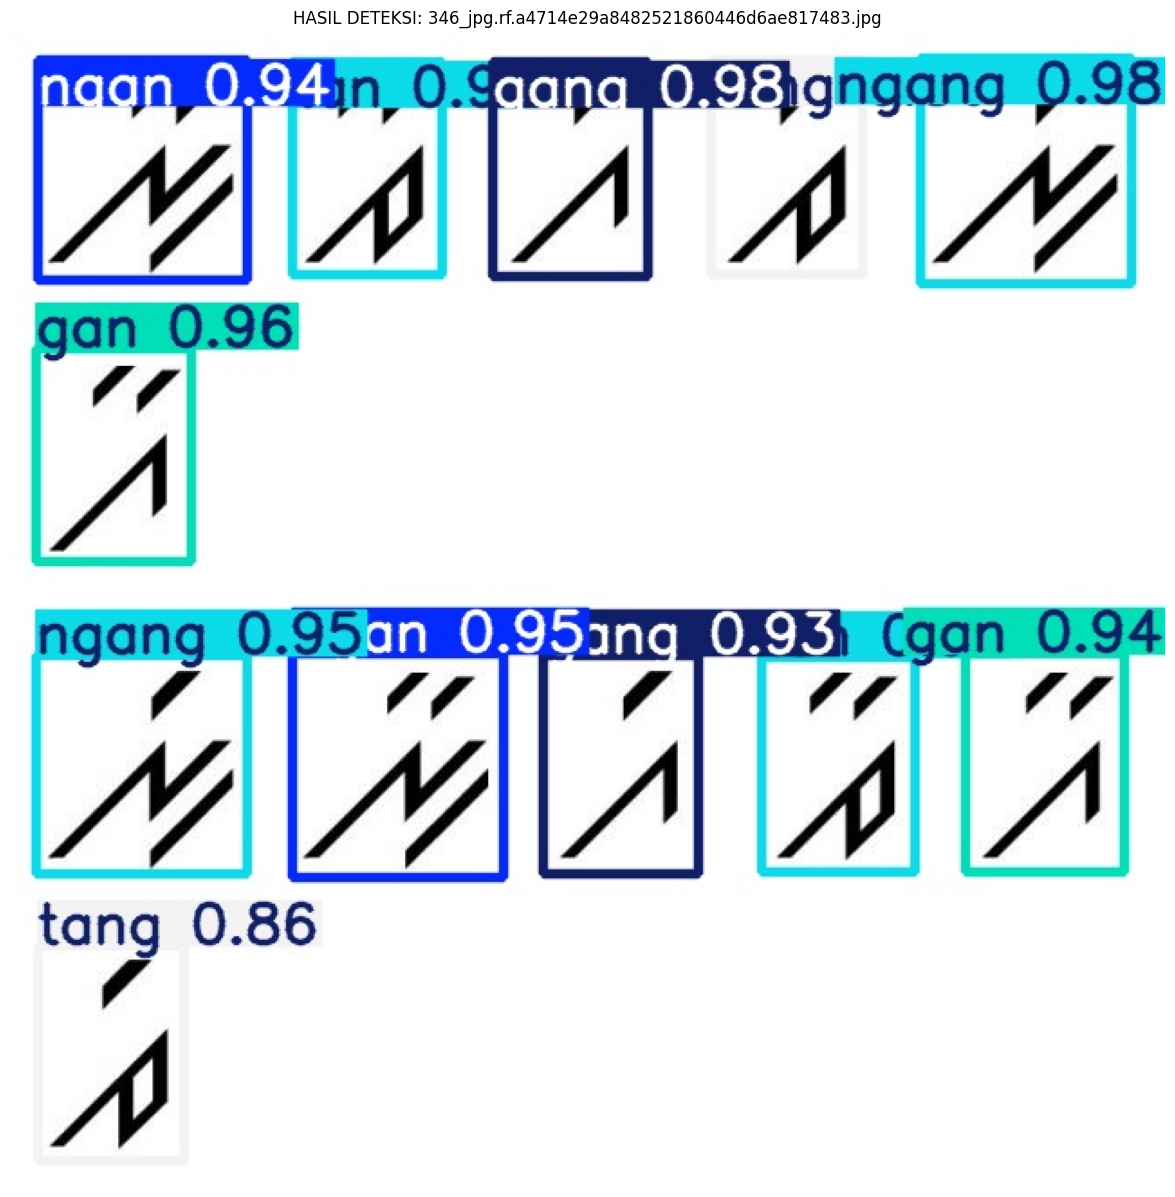

In [ ]:
## CELL 13 - TAMPILKAN HASIL DETEKSI

import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# folder hasil predict
predict_folder = "/content/runs/detect/predict"

# ambil semua file
files = os.listdir(predict_folder)

# tampilkan daftar file
print(files)

# pilih gambar
index = 57

# ambil nama gambar
img_name = files[index]

# gabungkan path
img_path = os.path.join(
    predict_folder,
    img_name
)

# baca gambar
img = mpimg.imread(img_path)

# tampilkan gambar
plt.figure(figsize=(15,15))
plt.imshow(img)

plt.title(f"HASIL DETEKSI: {img_name}")

plt.axis("off")
plt.show()

In [ ]:
## CELL 14 - EXPORT MODEL

best_model.export(format="onnx")

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)

PyTorch: starting from '/content/runs/detect/train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 257, 8400) (49.9 MB)

ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.93...
ONNX: export success ✅ 8.0s, saved as '/content/runs/detect/train/weights/best.onnx' (99.4 MB)

Export complete (9.8s)
Results saved to /content/runs/detect/train/weights/best.onnx
Predict:         yolo predict task=detect model=/content/runs/detect/train/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/content/runs/detect/train/weights/best.onnx imgsz=640 data=/content/Aksara-Ulu-Rejang-4/data.yaml  
Visualize:       https://netron.app


'/content/runs/detect/train/weights/best.onnx'

In [ ]:
import os

test_path = "/content/Aksara-Ulu-Rejang-4/test/images"

files = os.listdir(test_path)

for i, file in enumerate(files[:30]):
    print(i, file)

0 635_jpg.rf.86431792f72b0e3da95e6172fe40f8f2.jpg
1 480_jpg.rf.ff3d3b89c18389f0a3557cb7b7755724.jpg
2 89_jpg.rf.3638e8d9f1bdba4f5593ff0c0b4a0d54.jpg
3 491_jpg.rf.eec36c835752047c71187180d916b0ef.jpg
4 675_jpg.rf.f77c8a82dd96d9e8a16c38d72806a16b.jpg
5 547_jpg.rf.0517e4b8453327236d2954fb14dcc755.jpg
6 420_jpg.rf.750591bb0229d9f80f378341e81a98e7.jpg
7 232_jpg.rf.15474eea671ae9c781f739dfd17fd49d.jpg
8 467_jpg.rf.61bfc7dad79b0724711383c595cd459f.jpg
9 297_jpg.rf.2cf6f6f84d76edd97dec97de3b63e693.jpg
10 601_jpg.rf.ecd2c8d6f0f11a9361d187e88274c574.jpg
11 383_jpg.rf.8dab2c45e7498daabe35cc5e18317847.jpg
12 282_jpg.rf.d34a68b1cb4ba09a517e967566586b67.jpg
13 597_jpg.rf.c4430e5c146efe146bfd0c93fb5c20aa.jpg
14 564_jpg.rf.fac0f8cdc16de7c437cab3454fed43a6.jpg
15 489_jpg.rf.eeba2682e9621806b0d7d71d0edd6646.jpg
16 130_jpg.rf.abad26f41d85ff7238cf08b24ff20ed3.jpg
17 355_jpg.rf.e582adb89a88e62a81a27b5155bf1c89.jpg
18 270_jpg.rf.e15d37e6112d6215ab69e9270a83ef0e.jpg
19 104_jpg.rf.81823e61e224273562ee260f5812